<a href="https://colab.research.google.com/github/rachakondasaivarshini/AIML-EXPS/blob/main/AIML_EXPS_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Support Vectors (RBF Kernel):
[20 20]

Support Vectors (Polynomial Kernel):
[24 22]


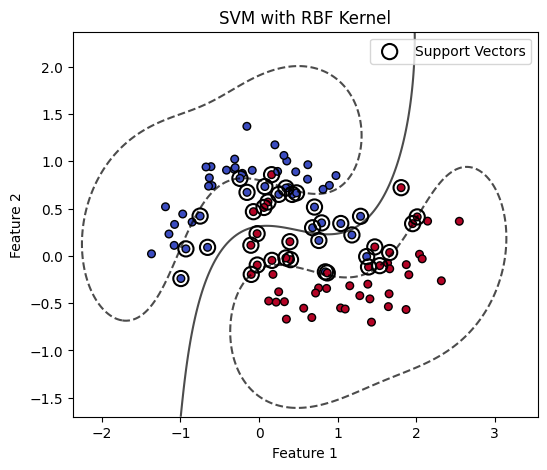

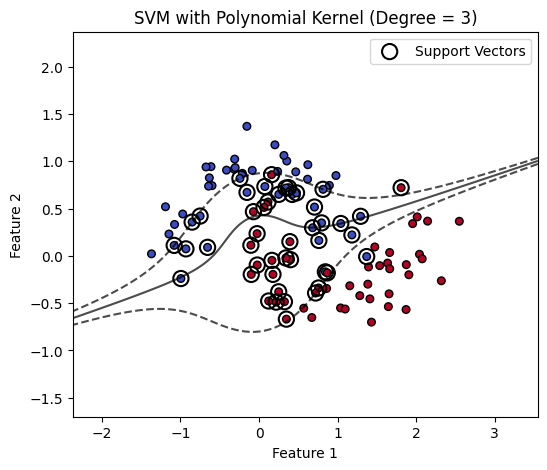

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC

# Step 1: Create non-linear dataset (Two Moons)
X, y = make_moons(
    n_samples=100,
    noise=0.2,
    random_state=42
)

# Step 2: Define SVM models

# RBF Kernel SVM
svm_rbf = SVC(
    kernel='rbf',
    C=1,
    gamma=0.5
)

# Polynomial Kernel SVM (Degree 3)
svm_poly = SVC(
    kernel='poly',
    degree=3,
    C=1
)

# Step 3: Train the models
svm_rbf.fit(X, y)
svm_poly.fit(X, y)

# Print support vectors count
print("Support Vectors (RBF Kernel):")
print(svm_rbf.n_support_)

print("\nSupport Vectors (Polynomial Kernel):")
print(svm_poly.n_support_)

# Step 4: Function to plot decision boundary, margins and support vectors

def plot_svm(model, X, y, title):

    plt.figure(figsize=(6, 5))

    # Plot data points
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap=plt.cm.coolwarm,
        s=30,
        edgecolors='k'
    )

    # Create mesh grid
    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1

    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    # Predict decision function
    Z = model.decision_function(
        np.c_[xx.ravel(), yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    # Draw decision boundary and margins
    plt.contour(
        xx,
        yy,
        Z,
        colors='black',
        levels=[-1, 0, 1],
        alpha=0.7,
        linestyles=['--', '-', '--']
    )

    # Highlight support vectors
    plt.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=120,
        linewidth=1.5,
        facecolors='none',
        edgecolors='black',
        label='Support Vectors'
    )

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()


# Step 5: Visualize both kernels

plot_svm(
    svm_rbf,
    X,
    y,
    "SVM with RBF Kernel"
)

plot_svm(
    svm_poly,
    X,
    y,
    "SVM with Polynomial Kernel (Degree = 3)"
)